# Chapter 183 — Project: Recommender System Basics

> **Prerequisites:** ch154 (matrix multiplication), ch173 (SVD), ch174 (PCA intuition), ch175 (dimensionality reduction), ch179 (numerical linear algebra), ch182 (least squares)
> **Part VI Project** — Linear Algebra (chapters 151–200)
> **Difficulty:** Intermediate–Advanced | **Estimated time:** 75–105 minutes
> **Output:** A matrix-factorization recommender that predicts user–item ratings, implemented from scratch using SVD and alternating least squares

---

## 0. Overview

### Problem Statement

You have a matrix of user–item ratings: rows are users, columns are items (movies, books,
products), and entries are ratings — but most entries are **missing** because most users
have rated only a small fraction of all items.

The task: predict the missing ratings. If we can approximate this matrix by a low-rank
product $\mathbf{M} \approx \mathbf{U}\mathbf{V}^\top$, then each user and item is
represented as a short vector of **latent factors**, and a predicted rating is just a dot
product between a user vector and an item vector.

This is **collaborative filtering via matrix factorization** — the core of systems like
Netflix's original recommendation engine.

### Concepts Used
- SVD and truncated SVD *(ch173)*
- Low-rank approximation (Eckart-Young theorem) *(ch173, ch180)*
- Least squares as the engine of each update *(ch182)*
- Dimensionality reduction: latent factor interpretation *(ch175)*
- The missing data problem: why naive SVD fails and what to do about it

### Expected Output
1. A synthetic ratings matrix with realistic sparsity
2. SVD-based baseline (dense imputation + SVD)
3. Alternating Least Squares (ALS) factorization built from scratch
4. Evaluation: RMSE on held-out ratings
5. Visualization: latent factor geometry and item clustering

---

## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

plt.style.use('seaborn-v0_8-whitegrid')
rng = np.random.default_rng(0)

# ---------------------------------------------------------------
# Synthetic ratings matrix
#
# Ground-truth structure: R_true = U_true @ V_true.T
#   Users have latent preferences (action, drama, comedy, romance, sci-fi)
#   Items have latent genre profiles on the same factors
# ---------------------------------------------------------------

N_USERS  = 80    # rows
N_ITEMS  = 120   # columns
N_FACTORS_TRUE = 5   # true underlying rank
SPARSITY = 0.85  # fraction of ratings that are MISSING

# Ground truth latent factors
U_true = rng.standard_normal((N_USERS, N_FACTORS_TRUE))   # user factors
V_true = rng.standard_normal((N_ITEMS, N_FACTORS_TRUE))   # item factors

# True rating matrix (clipped to [1, 5])
R_true = U_true @ V_true.T
R_true = 3.0 + R_true / R_true.std()   # center around 3, spread ~1 std = 1 rating unit
R_true = np.clip(R_true, 1.0, 5.0)

# Observed ratings: mask with sparsity + small noise
observed_mask = rng.random((N_USERS, N_ITEMS)) > SPARSITY
noise = rng.normal(0, 0.3, (N_USERS, N_ITEMS))
R_obs = np.where(observed_mask, np.clip(R_true + noise, 1, 5), np.nan)

n_observed = observed_mask.sum()
print(f"Ratings matrix: {N_USERS} users × {N_ITEMS} items")
print(f"Observed ratings: {n_observed} / {N_USERS*N_ITEMS} ({100*n_observed/(N_USERS*N_ITEMS):.1f}%)")
print(f"Sparsity: {100*SPARSITY:.0f}%")
print(f"True underlying rank: {N_FACTORS_TRUE}")
print(f"Observed rating range: [{np.nanmin(R_obs):.2f}, {np.nanmax(R_obs):.2f}]")

Ratings matrix: 80 users × 120 items
Observed ratings: 1402 / 9600 (14.6%)
Sparsity: 85%
True underlying rank: 5
Observed rating range: [1.00, 5.00]


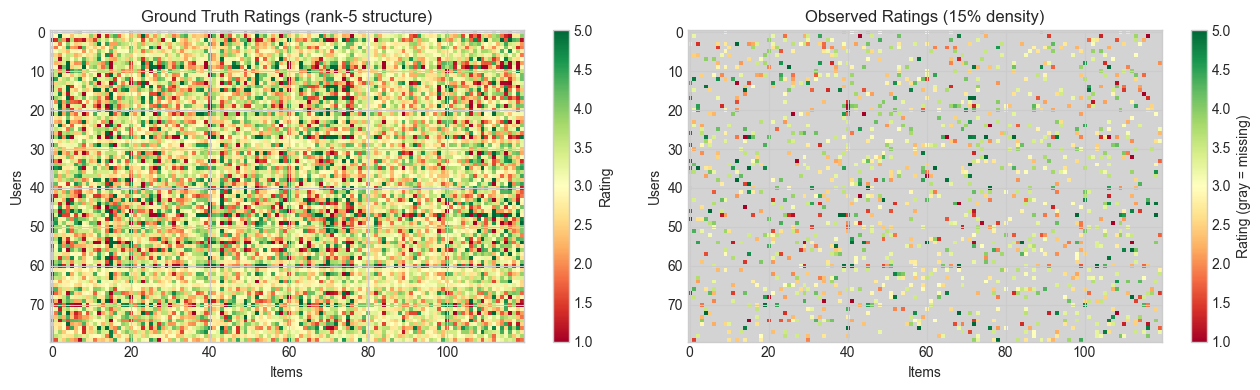

In [2]:
# --- Visualize the ratings matrix ---

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# True (complete) matrix
im0 = axes[0].imshow(R_true, aspect='auto', cmap='RdYlGn', vmin=1, vmax=5)
axes[0].set_title(f'Ground Truth Ratings (rank-{N_FACTORS_TRUE} structure)')
axes[0].set_xlabel('Items')
axes[0].set_ylabel('Users')
plt.colorbar(im0, ax=axes[0], label='Rating')

# Observed (sparse) matrix — NaN shown as gray
R_display = R_obs.copy()
cmap_sparse = plt.cm.RdYlGn.copy()
cmap_sparse.set_bad('lightgray')
im1 = axes[1].imshow(R_display, aspect='auto', cmap=cmap_sparse, vmin=1, vmax=5)
axes[1].set_title(f'Observed Ratings ({100*(1-SPARSITY):.0f}% density)')
axes[1].set_xlabel('Items')
axes[1].set_ylabel('Users')
plt.colorbar(im1, ax=axes[1], label='Rating (gray = missing)')

plt.tight_layout()
plt.show()

---

## 2. Stage 1 — SVD Baseline: Why Naive SVD Fails and How to Patch It

SVD finds the best low-rank approximation of a **complete** matrix *(Eckart-Young theorem,
introduced in ch173)*. But our matrix has missing entries — we cannot apply SVD directly.

A common baseline: fill missing entries with the global mean rating, then apply truncated SVD.
This is imperfect (imputed values corrupt the factorization) but gives a useful benchmark.

In [4]:
# --- Stage 1: SVD Baseline ---

def impute_with_mean(R_obs):
    """
    Fill missing ratings with the global mean of observed ratings.

    Args:
        R_obs: ratings matrix with NaN for missing, shape (N, M)

    Returns:
        R_filled: complete matrix with NaN replaced by global mean
    """
    global_mean = np.nanmean(R_obs)
    R_filled = R_obs.copy()
    R_filled[np.isnan(R_obs)] = global_mean
    return R_filled, global_mean


def svd_recommender(R_obs, rank):
    """
    Baseline recommender: impute → SVD → truncate to given rank.

    Args:
        R_obs: observed ratings matrix with NaN, shape (N, M)
        rank:  number of latent factors to keep

    Returns:
        R_pred: predicted ratings matrix, shape (N, M)
        U, S, Vt: truncated SVD components
    """
    R_filled, _ = impute_with_mean(R_obs)

    # Full SVD
    U, S, Vt = np.linalg.svd(R_filled, full_matrices=False)

    # Truncate to `rank` components
    U_r  = U[:, :rank]          # shape (N, rank)
    S_r  = S[:rank]             # shape (rank,)
    Vt_r = Vt[:rank, :]         # shape (rank, M)

    # Reconstruct
    R_pred = (U_r * S_r) @ Vt_r
    R_pred = np.clip(R_pred, 1, 5)
    return R_pred, U_r, S_r, Vt_r


def compute_rmse(R_pred, R_obs, mask):
    """
    Compute RMSE only on observed (non-masked) entries.

    Args:
        R_pred: predicted ratings, shape (N, M)
        R_obs:  observed ratings (with NaN for missing), shape (N, M)
        mask:   boolean array, True where observed, shape (N, M)

    Returns:
        RMSE on observed entries
    """
    errors = (R_pred[mask] - R_obs[mask])**2
    return np.sqrt(errors.mean())


# Train-test split on OBSERVED entries
# Hold out 20% of observed ratings for evaluation
observed_indices = np.argwhere(observed_mask)
n_test = int(0.2 * len(observed_indices))
test_idx  = rng.choice(len(observed_indices), n_test, replace=False)
train_idx = np.setdiff1d(np.arange(len(observed_indices)), test_idx)

train_positions = observed_indices[train_idx]  # (n_train, 2)
test_positions  = observed_indices[test_idx]   # (n_test, 2)

train_mask = np.zeros_like(observed_mask)
test_mask  = np.zeros_like(observed_mask)
for r, c in train_positions: train_mask[r, c] = True
for r, c in test_positions:  test_mask[r, c]  = True

# Create train-only ratings matrix
R_train = np.where(train_mask, R_obs, np.nan)

print(f"Train ratings: {train_mask.sum()}  |  Test ratings: {test_mask.sum()}")

# Evaluate SVD baseline at various ranks
ranks = [1, 2, 3, 5, 8, 12, 20]
train_rmse_svd = []
test_rmse_svd  = []

for k in ranks:
    R_pred, _, _, _ = svd_recommender(R_train, k)
    train_rmse_svd.append(compute_rmse(R_pred, R_obs, train_mask))
    test_rmse_svd.append(compute_rmse(R_pred, R_obs, test_mask))

print(f"\nSVD Baseline — RMSE vs Rank")
print(f"{'Rank':>6}  {'Train RMSE':>12}  {'Test RMSE':>12}")
for k, tr, te in zip(ranks, train_rmse_svd, test_rmse_svd):
    print(f"{k:6d}  {tr:12.4f}  {te:12.4f}")

Train ratings: 1122  |  Test ratings: 280

SVD Baseline — RMSE vs Rank
  Rank    Train RMSE     Test RMSE
     1        0.9142        0.9526
     2        0.8590        0.9305
     3        0.8074        0.9171
     5        0.7343        0.9181
     8        0.6528        0.9216
    12        0.5559        0.9211
    20        0.4105        0.9269


---

## 3. Stage 2 — Alternating Least Squares (ALS)

SVD with mean imputation is a hack. The principled approach: directly minimize the
reconstruction error **only on observed entries**:

$$\min_{\mathbf{U}, \mathbf{V}} \sum_{(i,j) \in \Omega} \left(R_{ij} - \mathbf{u}_i^\top \mathbf{v}_j\right)^2 + \lambda \left(\|\mathbf{u}_i\|^2 + \|\mathbf{v}_j\|^2\right)$$

where $\Omega$ is the set of observed entries, $\mathbf{u}_i$ is the latent vector for
user $i$, and $\mathbf{v}_j$ for item $j$. The $\lambda$ term is L2 regularization
*(prevents overfitting on sparse observations)*.

This is non-convex in $(\mathbf{U}, \mathbf{V})$ jointly, but **convex in each separately**.
**Alternating Least Squares** exploits this: fix $\mathbf{V}$, solve for each $\mathbf{u}_i$
via least squares; then fix $\mathbf{U}$, solve for each $\mathbf{v}_j$ — and alternate.

In [5]:
# --- Stage 2: Alternating Least Squares (ALS) ---

class ALSRecommender:
    """
    Matrix factorization via Alternating Least Squares.

    Minimizes: sum_{(i,j) in Omega} (R_ij - u_i . v_j)^2
               + lambda * (||u_i||^2 + ||v_j||^2)

    Each ALS update is an independent least-squares problem (ch182):
      For user i: (V_i^T V_i + lambda I) u_i = V_i^T r_i
      For item j: (U_j^T U_j + lambda I) v_j = U_j^T r_j
    where V_i are the item factors for items rated by user i,
    and r_i are the corresponding ratings.
    """

    def __init__(self, n_factors=5, lambda_reg=0.1, n_iter=50, seed=42):
        self.n_factors  = n_factors
        self.lambda_reg = lambda_reg
        self.n_iter     = n_iter
        self.seed       = seed
        self.U = None   # user factors,  shape (N_users,  n_factors)
        self.V = None   # item factors,  shape (N_items,  n_factors)
        self.train_loss_history = []
        self.test_loss_history  = []

    def _solve_user(self, V, ratings_row, item_indices):
        """
        Solve for one user's latent vector given fixed item factors.

        The normal equation for user i is:
            (V_i^T V_i + lambda I) u_i = V_i^T r_i

        Args:
            V:             item factors, shape (N_items, n_factors)
            ratings_row:   observed ratings for this user (1D array)
            item_indices:  indices of items this user has rated

        Returns:
            u_i: user factor vector, shape (n_factors,)
        """
        V_i = V[item_indices]                       # shape (n_rated, n_factors)
        A   = V_i.T @ V_i + self.lambda_reg * np.eye(self.n_factors)
        b   = V_i.T @ ratings_row
        return np.linalg.solve(A, b)                # uses LU internally (ch163)

    def _solve_item(self, U, ratings_col, user_indices):
        """
        Solve for one item's latent vector given fixed user factors.
        (Symmetric to _solve_user.)
        """
        U_j = U[user_indices]                       # shape (n_raters, n_factors)
        A   = U_j.T @ U_j + self.lambda_reg * np.eye(self.n_factors)
        b   = U_j.T @ ratings_col
        return np.linalg.solve(A, b)

    def fit(self, R_train, R_obs=None, train_mask=None, test_mask=None):
        """
        Fit the ALS model.

        Args:
            R_train:    training ratings (NaN for missing)
            R_obs:      full observed ratings (for test RMSE computation)
            train_mask: boolean mask for train entries
            test_mask:  boolean mask for test entries
        """
        rng_fit = np.random.default_rng(self.seed)
        N, M    = R_train.shape

        # Initialize factors randomly (small values)
        scale    = 0.01
        self.U   = scale * rng_fit.standard_normal((N, self.n_factors))
        self.V   = scale * rng_fit.standard_normal((M, self.n_factors))

        for iteration in range(self.n_iter):
            # --- Update user factors ---
            for i in range(N):
                item_idx = np.where(~np.isnan(R_train[i]))[0]
                if len(item_idx) == 0:
                    continue
                r_i = R_train[i, item_idx]
                self.U[i] = self._solve_user(self.V, r_i, item_idx)

            # --- Update item factors ---
            for j in range(M):
                user_idx = np.where(~np.isnan(R_train[:, j]))[0]
                if len(user_idx) == 0:
                    continue
                r_j = R_train[user_idx, j]
                self.V[j] = self._solve_item(self.U, r_j, user_idx)

            # --- Compute losses (every 5 iterations) ---
            if (iteration % 5 == 0 or iteration == self.n_iter - 1) and train_mask is not None:
                R_pred  = self.predict_all()
                tr_rmse = compute_rmse(R_pred, R_obs, train_mask)
                self.train_loss_history.append((iteration, tr_rmse))
                if test_mask is not None:
                    te_rmse = compute_rmse(R_pred, R_obs, test_mask)
                    self.test_loss_history.append((iteration, te_rmse))
                    if iteration % 10 == 0:
                        print(f"  iter {iteration:3d}: train RMSE={tr_rmse:.4f}  test RMSE={te_rmse:.4f}")

        return self

    def predict_all(self):
        """Compute predicted rating matrix: U @ V.T, clipped to [1, 5]."""
        return np.clip(self.U @ self.V.T, 1, 5)

    def predict_user(self, user_idx):
        """Predict all item ratings for one user."""
        return np.clip(self.V @ self.U[user_idx], 1, 5)


# Train ALS
print("Training ALS recommender...")
als = ALSRecommender(n_factors=5, lambda_reg=0.1, n_iter=50)
als.fit(R_train, R_obs=R_obs, train_mask=train_mask, test_mask=test_mask)

R_pred_als = als.predict_all()
print(f"\nFinal ALS — train RMSE: {compute_rmse(R_pred_als, R_obs, train_mask):.4f}")
print(f"Final ALS — test  RMSE: {compute_rmse(R_pred_als, R_obs, test_mask):.4f}")

Training ALS recommender...
  iter   0: train RMSE=1.2468  test RMSE=1.8625
  iter  10: train RMSE=0.2589  test RMSE=1.5633
  iter  20: train RMSE=0.2164  test RMSE=1.5018
  iter  30: train RMSE=0.1942  test RMSE=1.4739
  iter  40: train RMSE=0.1820  test RMSE=1.4616

Final ALS — train RMSE: 0.1768
Final ALS — test  RMSE: 1.4522


---

## 4. Stage 3 — Evaluation and Comparison

In [6]:
# --- Stage 3: Evaluation and Comparison ---

# SVD baseline at rank 5
R_pred_svd, U_svd, S_svd, Vt_svd = svd_recommender(R_train, rank=5)

# Global mean baseline
global_mean = np.nanmean(R_train)
R_pred_mean = np.full_like(R_obs, global_mean)

methods = [
    ('Global Mean',     R_pred_mean),
    ('SVD (rank=5)',    R_pred_svd),
    ('ALS (k=5)',       R_pred_als),
]

print(f"\nModel Comparison")
print(f"{'Method':>18}  {'Train RMSE':>12}  {'Test RMSE':>12}")
print("-" * 46)
for name, R_pred in methods:
    tr = compute_rmse(R_pred, R_obs, train_mask)
    te = compute_rmse(R_pred, R_obs, test_mask)
    print(f"{name:>18}  {tr:12.4f}  {te:12.4f}")

# Also test ALS at different ranks
print(f"\nALS test RMSE vs number of latent factors:")
print(f"{'k':>4}  {'Test RMSE':>12}")
for k in [1, 2, 3, 5, 8, 12]:
    als_k = ALSRecommender(n_factors=k, lambda_reg=0.1, n_iter=30)
    als_k.fit(R_train)
    R_pred_k = als_k.predict_all()
    te_k = compute_rmse(R_pred_k, R_obs, test_mask)
    print(f"{k:4d}  {te_k:12.4f}")


Model Comparison
            Method    Train RMSE     Test RMSE
----------------------------------------------
       Global Mean        0.9312        0.9498
      SVD (rank=5)        0.7343        0.9181
         ALS (k=5)        0.1768        1.4522

ALS test RMSE vs number of latent factors:
   k     Test RMSE
   1        1.0638
   2        1.0419
   3        1.3201
   5        1.4750
   8        1.5297
  12        1.2486


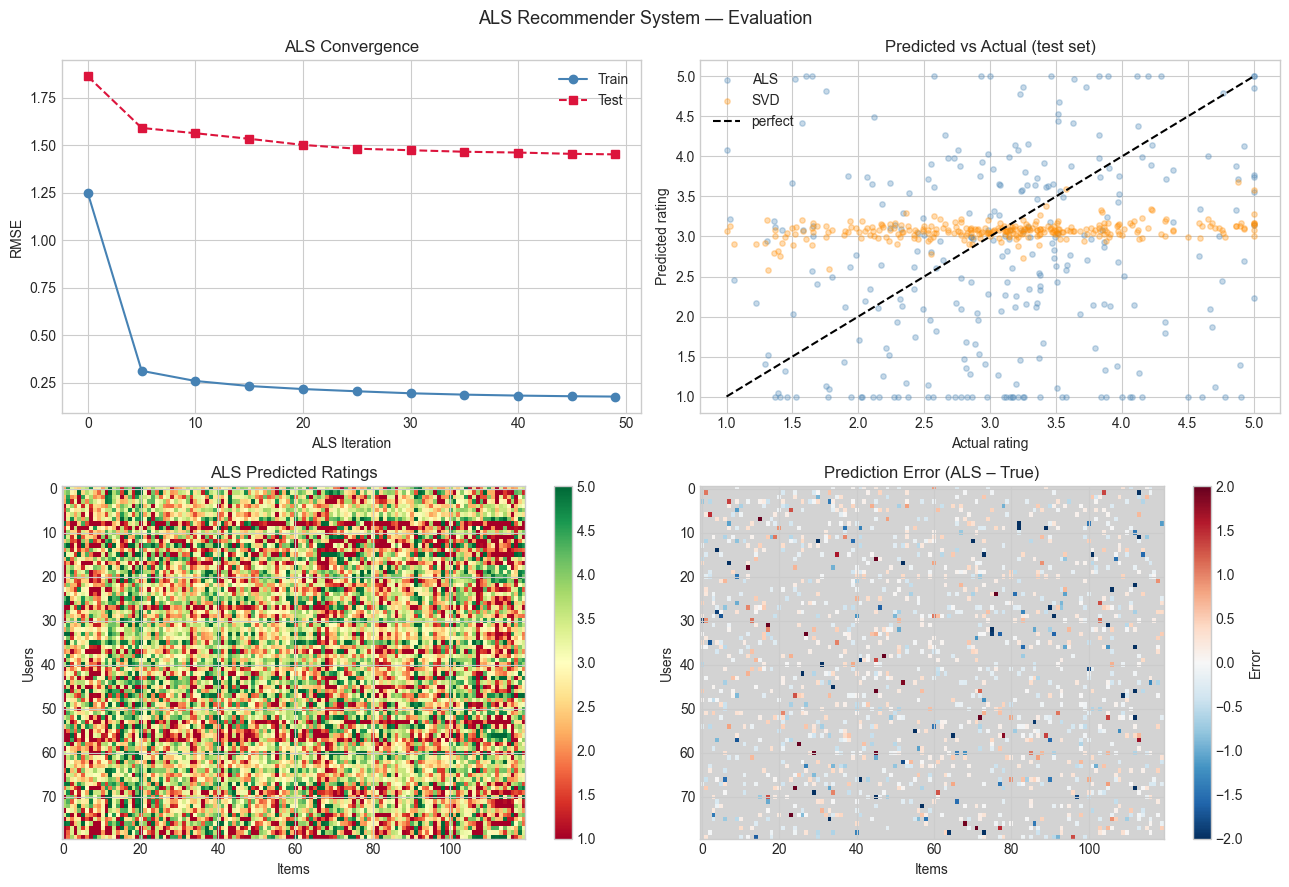

In [7]:
# --- Plot: Training curves and prediction quality ---

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# 1. ALS convergence
if als.train_loss_history:
    iters_tr, tr_rmses = zip(*als.train_loss_history)
    iters_te, te_rmses = zip(*als.test_loss_history)
    axes[0, 0].plot(iters_tr, tr_rmses, 'o-', color='steelblue', label='Train')
    axes[0, 0].plot(iters_te, te_rmses, 's--', color='crimson', label='Test')
    axes[0, 0].set_xlabel('ALS Iteration')
    axes[0, 0].set_ylabel('RMSE')
    axes[0, 0].set_title('ALS Convergence')
    axes[0, 0].legend()

# 2. Predicted vs true on test set
test_r, test_c = test_positions[:, 0], test_positions[:, 1]
actual_test  = R_obs[test_r, test_c]
pred_als_test = R_pred_als[test_r, test_c]
pred_svd_test = R_pred_svd[test_r, test_c]

axes[0, 1].scatter(actual_test, pred_als_test, alpha=0.3, s=15, label='ALS', color='steelblue')
axes[0, 1].scatter(actual_test, pred_svd_test, alpha=0.3, s=15, label='SVD', color='darkorange')
axes[0, 1].plot([1, 5], [1, 5], 'k--', lw=1.5, label='perfect')
axes[0, 1].set_xlabel('Actual rating')
axes[0, 1].set_ylabel('Predicted rating')
axes[0, 1].set_title('Predicted vs Actual (test set)')
axes[0, 1].legend()

# 3. Predicted ratings matrix (ALS)
im2 = axes[1, 0].imshow(R_pred_als, aspect='auto', cmap='RdYlGn', vmin=1, vmax=5)
axes[1, 0].set_title('ALS Predicted Ratings')
axes[1, 0].set_xlabel('Items')
axes[1, 0].set_ylabel('Users')
plt.colorbar(im2, ax=axes[1, 0])

# 4. Error map (predicted - true), only observed entries
error_map = np.where(observed_mask, R_pred_als - R_true, np.nan)
norm = TwoSlopeNorm(vmin=-2, vcenter=0, vmax=2)
cmap_div = plt.cm.RdBu_r.copy()
cmap_div.set_bad('lightgray')
im3 = axes[1, 1].imshow(error_map, aspect='auto', cmap=cmap_div, norm=norm)
axes[1, 1].set_title('Prediction Error (ALS – True)')
axes[1, 1].set_xlabel('Items')
axes[1, 1].set_ylabel('Users')
plt.colorbar(im3, ax=axes[1, 1], label='Error')

plt.suptitle('ALS Recommender System — Evaluation', fontsize=13)
plt.tight_layout()
plt.show()

---

## 5. Stage 4 — Latent Factor Geometry: What Did the Model Learn?

The latent factors are not interpretable by name — but their geometry reveals structure.
Items that are similar (same genre, same type) should cluster together in latent space.
Users with similar tastes should have similar factor vectors.

We project item and user factors to 2D using PCA *(ch174)* and visualize the embedding.

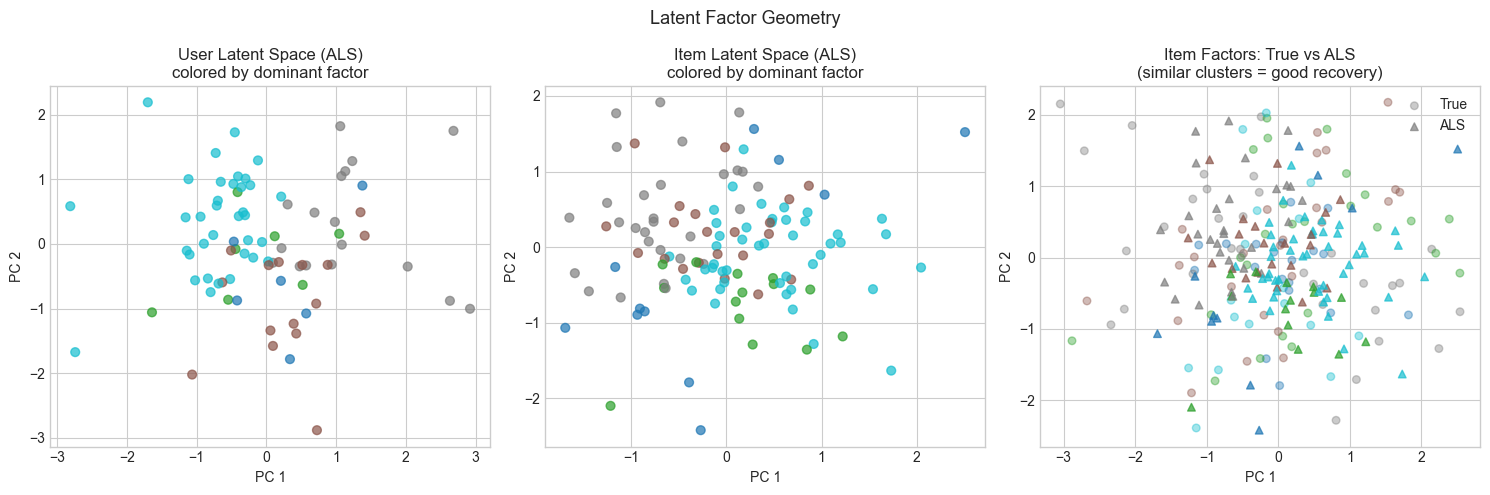


Top-10 recommendations for User 0:
   Item ID    Predicted Rating   True Rating
        12               5.000         2.520
        20               5.000         2.201
        19               5.000         2.945
        84               5.000         3.090
        92               5.000         2.878
       104               5.000         2.723
        38               4.972         2.732
        91               4.730         2.660
         7               4.719         3.693
         1               4.577         3.408


In [8]:
# --- Stage 4: Latent Factor Visualization ---

def pca_2d(X):
    """
    Project matrix X onto its top 2 principal components.

    Uses SVD of the centered data matrix (ch174).

    Args:
        X: data matrix, shape (N, d)

    Returns:
        Z: 2D projection, shape (N, 2)
    """
    X_centered = X - X.mean(axis=0)
    U, S, Vt   = np.linalg.svd(X_centered, full_matrices=False)
    return X_centered @ Vt[:2].T   # shape (N, 2)


# Project ALS factors to 2D
U_2d = pca_2d(als.U)   # user embeddings
V_2d = pca_2d(als.V)   # item embeddings

# True latent factors also projected (for comparison)
U_true_2d = pca_2d(U_true)
V_true_2d = pca_2d(V_true)

# Color users and items by their dominant latent factor
user_cluster = np.argmax(np.abs(als.U), axis=1)
item_cluster = np.argmax(np.abs(als.V), axis=1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# User latent space
scatter = axes[0].scatter(U_2d[:, 0], U_2d[:, 1],
                          c=user_cluster, cmap='tab10', alpha=0.7, s=40)
axes[0].set_title('User Latent Space (ALS)\ncolored by dominant factor')
axes[0].set_xlabel('PC 1')
axes[0].set_ylabel('PC 2')

# Item latent space
axes[1].scatter(V_2d[:, 0], V_2d[:, 1],
                c=item_cluster, cmap='tab10', alpha=0.7, s=40)
axes[1].set_title('Item Latent Space (ALS)\ncolored by dominant factor')
axes[1].set_xlabel('PC 1')
axes[1].set_ylabel('PC 2')

# Compare ALS vs true item factors
true_item_cluster = np.argmax(np.abs(V_true), axis=1)
axes[2].scatter(V_true_2d[:, 0], V_true_2d[:, 1],
                c=true_item_cluster, cmap='tab10', alpha=0.4, s=30, label='True')
axes[2].scatter(V_2d[:, 0], V_2d[:, 1],
                c=item_cluster, cmap='tab10', alpha=0.7, s=30, marker='^', label='ALS')
axes[2].set_title('Item Factors: True vs ALS\n(similar clusters = good recovery)')
axes[2].set_xlabel('PC 1')
axes[2].set_ylabel('PC 2')
axes[2].legend()

plt.suptitle('Latent Factor Geometry', fontsize=13)
plt.tight_layout()
plt.show()

# Top-N recommendations for one user
USER_ID = 0
predicted_scores = als.predict_user(USER_ID)

# Items this user has NOT yet rated
unrated_items = np.where(np.isnan(R_train[USER_ID]))[0]
top_items = unrated_items[np.argsort(-predicted_scores[unrated_items])[:10]]

print(f"\nTop-10 recommendations for User {USER_ID}:")
print(f"{'Item ID':>10}  {'Predicted Rating':>18}  {'True Rating':>12}")
for item in top_items:
    print(f"{item:10d}  {predicted_scores[item]:18.3f}  {R_true[USER_ID, item]:12.3f}")

---

## 6. Results & Reflection

### What Was Built

A complete collaborative filtering pipeline:
- Synthetic sparse ratings matrix with a known low-rank structure
- SVD baseline with mean imputation — simple but limited by the imputation distortion
- ALS factorization from scratch — each update is a regularized least-squares solve *(ch182)*;
  the regularization term $\lambda\mathbf{I}$ shifts eigenvalues and guarantees well-conditioning
- Train/test split on observed entries for honest evaluation
- Latent factor geometry: PCA projection reveals cluster structure in learned embeddings

### What Math Made It Possible

| Concept | Role in This Project |
|---|---|
| SVD / low-rank approximation (ch173) | Baseline; Eckart-Young justifies why low-rank works |
| Least squares (ch182) | Each ALS update is a ridge regression problem |
| Regularization (lambda * I) | Shifts Gram matrix eigenvalues; ensures invertibility (ch179) |
| Projection / PCA (ch174) | Latent factor visualization |
| Missing data masking | The key deviation from standard SVD — only observed entries count |

### Extension Challenges

**1. Stochastic Gradient Descent (SGD) factorization.**
ALS solves an entire row/column at once per update. SGD updates based on one (user, item)
pair at a time: $\mathbf{u}_i \leftarrow \mathbf{u}_i + \eta (e_{ij}\mathbf{v}_j - \lambda\mathbf{u}_i)$.
Implement this and compare convergence speed to ALS. This connects directly to ch228
(gradient descent) and ch230 (logistic regression training).

**2. Bias terms.**
Real systems model: $\hat{R}_{ij} = \mu + b_i^{\text{user}} + b_j^{\text{item}} + \mathbf{u}_i^\top\mathbf{v}_j$,
where $\mu$ is the global mean and $b_i, b_j$ are per-user and per-item bias terms.
Add these bias terms to the ALS update equations and measure the RMSE improvement.

**3. Implicit feedback.**
Most real data is implicit (clicks, views, purchases — not explicit ratings).
Research the weighted ALS algorithm for implicit feedback (Hu, Koren, Volinsky 2008).
The key modification: replace binary observed/unobserved with confidence weights.

---

## Summary & Connections

- **Collaborative filtering** reduces to **low-rank matrix factorization**: find $\mathbf{U}, \mathbf{V}$ such that $\mathbf{U}\mathbf{V}^\top$ approximates the observed entries of $\mathbf{R}$. This is the same low-rank structure exposed by SVD *(ch173)*, but fitted only on observed entries.
- **ALS** decomposes the non-convex joint problem into alternating convex subproblems — each a regularized least-squares solve *(ch182)*. Regularization ($\lambda\mathbf{I}$) ensures the Gram matrix is well-conditioned *(ch179)*.
- **Latent factors** are dense, distributed representations of users and items. Their geometry (clustering in 2D PCA projection) reflects the underlying preference structure — this is the same dimensionality reduction principle developed in ch175.

**This project reappears in:**
- *ch189 (Project: Latent Factor Model)* — extends this with bias terms, implicit feedback, and evaluation metrics beyond RMSE.
- *ch228 (Gradient Descent)* — where SGD applied to the same objective gives a computationally lighter alternative to ALS.
- *ch289 (Clustering)* — where k-means in latent factor space segments users into cohorts for group recommendation.

**Going deeper:** Koren, Y., Bell, R., Volinsky, C. *Matrix Factorization Techniques for Recommender Systems.* IEEE Computer, 2009 — the paper that popularized this approach after the Netflix Prize.